# **Create visualizations using Matplotib, Seaborn and Folium** 



### Installing Required Libraries


In [1]:
%pip install pandas -q
%pip install numpy -q
%pip install seaborn -q
%pip install folium -q
print('Installed !')

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Installed !


### Importing Required Libraries



In [2]:
import pandas as pd
import numpy as np
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import folium

---


# Scenario

Creating plots which answer questions for analysing "automobile_sales" data to understand the historical trends in automobile sales during recession periods.<br>
recession period 1 - year 1980 <br>
recession period 2 - year 1981 to 1982<br>
recession period 3 - year 1991<br>
recession period 4 - year 2000 to 2001<br>
recession period 5 - year end 2007 to mid 2009<br>
recession period 6 - year 2020 -Feb to April (Covid-19 Impact)<br>

# Data Description

The dataset used for this visualization assignment contains *automobile_sales* data representing automobile sales and related variables during recession and non-recession period. 

The dataset includes the following variables:
<br>1. Date: The month end date of sales observation.
<br>2. Recession: A binary variable indicating recession perion; 1 means it was recession, 0 means it was normal.
<br>3. Automobile_Sales: The number of vehicles sold during the period.
<br>4. GDP: The per capita GDP value in USD.
<br>5. Unemployment_Rate: The monthly unemployment rate.
<br>6. Consumer_Confidence: A synthetic index representing consumer confidence, which can impact consumer spending and automobile purchases.
<br>7. Seasonality_Weight: The weight representing the seasonality effect on automobile sales during the period. This variable represents the seasonal effect on automobile sales for a given month. In the automobile industry, sales often fluctuate throughout the year due to seasonal patterns—for example, sales may increase during the festive season or year-end promotions, and decrease during off-peak months like post-holiday winter periods.
A value greater than 1 indicates higher-than-average sales expected for that month due to seasonal trends (e.g., holiday season or new model launches).
A value less than 1 suggests lower-than-average sales due to seasonal slowdowns.
A value around 1 means the season has neutral or average effect on sales.
<br>8. Price: The average vehicle price during the period.
<br>9. Advertising_Expenditure: The advertising expenditure of the company.
<br>10.Vehicle_Type: The type of vehicles sold; Supperminicar, Smallfamiliycar,                 Mediumfamilycar, Executivecar, Sports.
<br>11.Competition: The measure of competition in the market, such as the number of competitors or market share of major manufacturers.
<br>12.Month: Month of the observation extracted from Date..
<br>13.Year: Year of the observation extracted from Date.
<br>
By examining various factors mentioned above from the dataset,  aiming to gain insights into how recessions impacted automobile sales for  company.


---


# Importing Data


In [3]:
import requests
import io

# URL of the CSV file
URL = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/d51iMGfp_t0QpO30Lym-dw/automobile-sales.csv"

# Fetch the data from the URL
response = requests.get(URL)

# Raise an error if the request failed
response.raise_for_status()

# Convert the response content into a readable format for pandas
csv_content = io.StringIO(response.text)

# Read the CSV data into a pandas dataframe
df = pd.read_csv(csv_content)

# Print confirmation
print('Data downloaded and read into a dataframe!')

print(df.head())

Data downloaded and read into a dataframe!
         Date  Year Month  Recession  Consumer_Confidence  Seasonality_Weight  \
0  1980-01-31  1980   Jan          1               108.24                0.45   
1  1980-01-31  1980   Jan          1               108.24                0.45   
2  1980-01-31  1980   Jan          1               108.24                0.36   
3  1980-01-31  1980   Jan          1               108.24                0.38   
4  1980-02-29  1980   Feb          1                98.75                0.46   

   Price  Advertising_Expenditure  Competition    GDP  Growth_Rate  \
0  27704                   1417.5            7  60.22         0.01   
1  77270                    763.7            7  60.22         0.01   
2  19665                   1417.5            7  60.22         0.01   
3  36986                   1417.5            7  60.22         0.01   
4  26609                   2773.4            4  45.99        -0.31   

   unemployment_rate  Automobile_Sales     Vehicl

In [4]:
df.describe()

,Year,Recession,Consumer_Confidence,Seasonality_Weight,Price,Advertising_Expenditure,Competition,GDP,Growth_Rate,unemployment_rate,Automobile_Sales
count,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000,2112.000000
mean,2001.520833,0.224432,101.210890,0.737756,41469.506155,2879.743655,6.118845,40.205748,-0.237074,2.441525,3164.160511
std,12.535031,0.417306,10.634092,0.286092,21388.409141,1175.338324,1.964292,16.291271,0.859691,1.108472,3640.137399
min,1980.000000,0.000000,73.900000,0.250000,15001.000000,494.200000,3.000000,12.510000,-4.230000,1.000000,40.000000
25%,1991.000000,0.000000,94.060000,0.500000,22039.000000,1872.000000,4.000000,27.210000,-0.570000,1.600000,923.000000
50%,2002.000000,0.000000,100.800000,0.810000,34957.500000,2883.500000,6.000000,39.420000,-0.005000,2.300000,2381.500000
75%,2012.000000,0.000000,108.320000,0.940000,57418.250000,3902.425000,8.000000,53.862500,0.392500,2.900000,4363.500000
max,2023.000000,1.000000,131.670000,1.500000,79998.000000,4983.000000,9.000000,70.370000,0.820000,6.000000,65645.000000


In [5]:
df.columns

Index(['Date', 'Year', 'Month', 'Recession', 'Consumer_Confidence',
       'Seasonality_Weight', 'Price', 'Advertising_Expenditure', 'Competition',
       'GDP', 'Growth_Rate', 'unemployment_rate', 'Automobile_Sales',
       'Vehicle_Type', 'City'],
      dtype='object')

---


# Creating Visualizations for Data Analysis


### TASK 1.1:  how Average automobile sales fluctuate from year to year


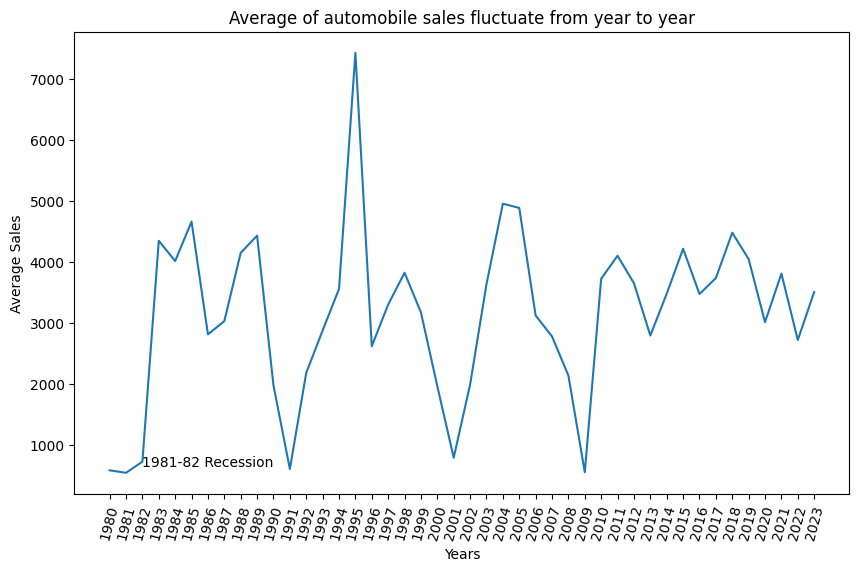

In [6]:

df_line = df.groupby(df['Year'])['Automobile_Sales'].mean()

#create figure
plt.figure(figsize=(10, 6))
df_line.plot(kind = 'line')
plt.xticks(list(range(1980,2024)), rotation = 75)
plt.xlabel('Years')
plt.ylabel('Average Sales')
plt.text(1982, 650, '1981-82 Recession')
plt.title('Average of automobile sales fluctuate from year to year')
plt.show()

---



####  TASK 1.2: Trends in advertising expenditure correlate with automobile sales during non-recession periods, and what insights can be derived from this relationship.


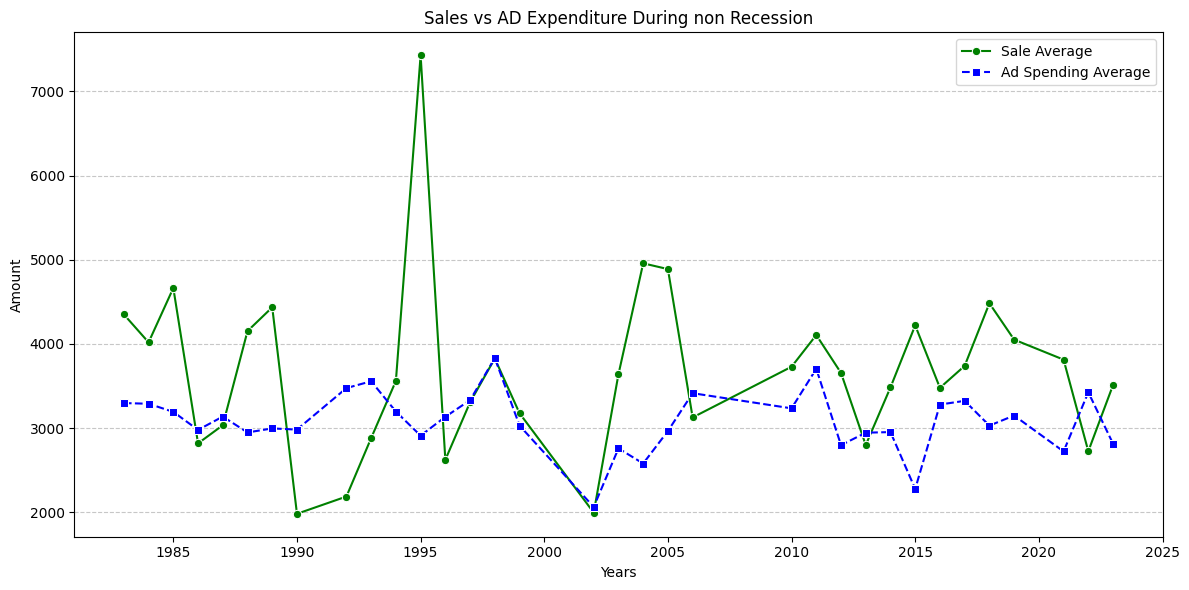

In [7]:
df_non_rec = df[df['Recession'] == 0]

# Calculate average automobile sales and average advertising expenditure by year (non-recession)
df_trends = df_non_rec.groupby('Year', as_index =  False).agg(
    Avg_Sales=('Automobile_Sales', 'mean'),
    Avg_Ad_Spend=('Advertising_Expenditure', 'mean')
)
# Create line plots for average sales and advertising expenditure over the years
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_trends, x = df_trends['Year'], y = df_trends['Avg_Sales'], marker='o', linestyle='-', color='green', label='Sale Average')
sns.lineplot(data=df_trends, x = df_trends['Year'], y = df_trends['Avg_Ad_Spend'], marker='s', linestyle='--', color='blue', label='Ad Spending Average')

# Add labels, legend, title, and grid
plt.xlabel('Years')
plt.ylabel('Amount')
plt.title('Sales vs AD Expenditure During non Recession')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show the plot
plt.tight_layout()
plt.show()

<details>
    <summary>Inference</summary>
<p>
Inference:
The graph shows that during non-recession periods, automobile sales are more volatile than advertising expenditure. While there are moments of alignment, sales often spike independently, suggesting other factors like market demand or economic conditions also play a significant role. The correlation between advertising and sales appears inconsistent over time.<br><br>
</p>
</details>

----


### TASK 1.3:  Create a visualization to compare the sales trend per vehicle type for a recession period with a non-recession period.


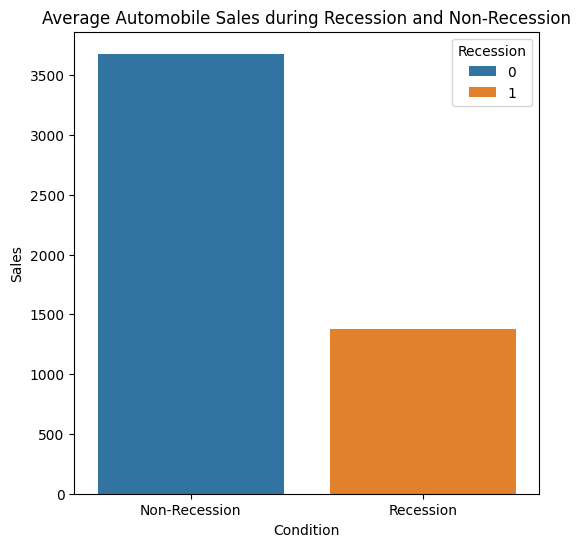

In [8]:
new_df = df.groupby('Recession')['Automobile_Sales'].mean().reset_index()
# Create the bar chart using seaborn
plt.figure(figsize=(6, 6) )
sns.barplot(x='Recession', y='Automobile_Sales', hue='Recession',  data=new_df)
plt.xlabel('Condition')
plt.ylabel('Sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.show()

###  To compare the sales of different vehicle types during a recession and a non-recession period



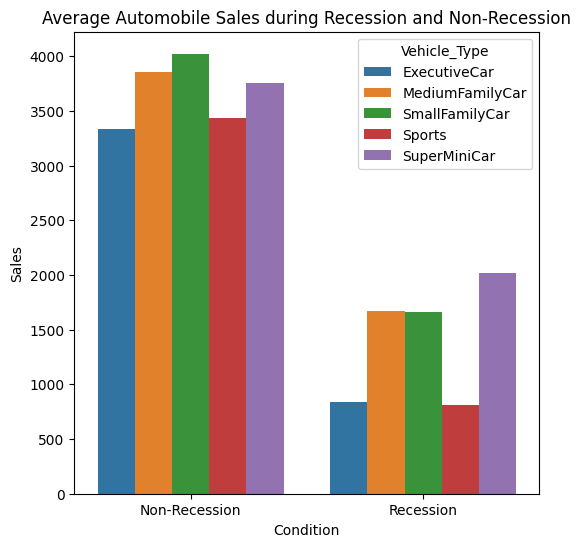

In [9]:
group_df = df.groupby(['Recession', 'Vehicle_Type'])['Automobile_Sales'].mean().reset_index()
# Create the bar chart using seaborn
plt.figure(figsize=(6, 6) )
sns.barplot(x='Recession', y='Automobile_Sales', hue='Vehicle_Type',  data = group_df)
plt.xlabel('Condition')
plt.ylabel('Sales')
plt.title('Average Automobile Sales during Recession and Non-Recession')
plt.xticks(ticks=[0, 1], labels=['Non-Recession', 'Recession'])
plt.show()

<details>
<summary>Inference</summary>

From this plot, we can understand that there is a drastic decline in the overall sales of the automobiles during recession.<br>However, the most affected type of vehicle is executivecar and sports<br><br>
</details>


---


### TASK 1.4:
#### How did the GDP vary over time during recession and non-recession periods? 



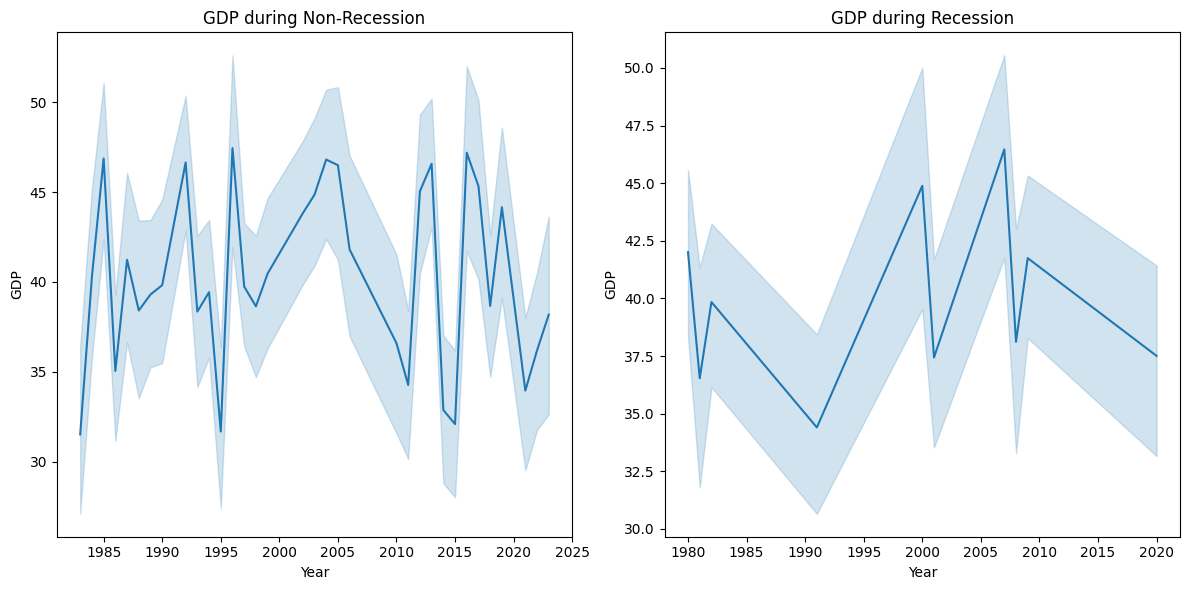

In [10]:
# Create dataframes
rec_data = df[df['Recession'] == 1]
non_rec_data = df[df['Recession'] == 0]

# Create figure
fig = plt.figure(figsize=(12, 6))

# Subplot 1: Non-Recession
ax1 = fig.add_subplot(1, 2, 1)
sns.lineplot(x='Year', y='GDP', data=non_rec_data, ax=ax1)
ax1.set_title('GDP during Non-Recession')
ax1.set_xlabel('Year')
ax1.set_ylabel('GDP')

# Subplot 2: Recession
ax2 = fig.add_subplot(1, 2, 2)
sns.lineplot(x='Year', y='GDP', data=rec_data, ax=ax2)
ax2.set_title('GDP during Recession')
ax2.set_xlabel('Year')
ax2.set_ylabel('GDP')

# Adjust layout
plt.tight_layout()
plt.show()

<details>
<summary>Inference</summary>
From this plot, it is evident that GDP tends to be lower and more volatile during recessions, with significant fluctuations and uncertainty. In contrast, non-recessionary periods show a relatively higher GDP level but still exhibit some degree of variability.<br><br></details>


---


### TASK 1.5: Develop a Bubble plot for displaying the impact of seasonality on Automobile Sales.
<br>How has seasonality impacted the sales, in which months the sales were high or low? Check it for non-recession years to understand the trend


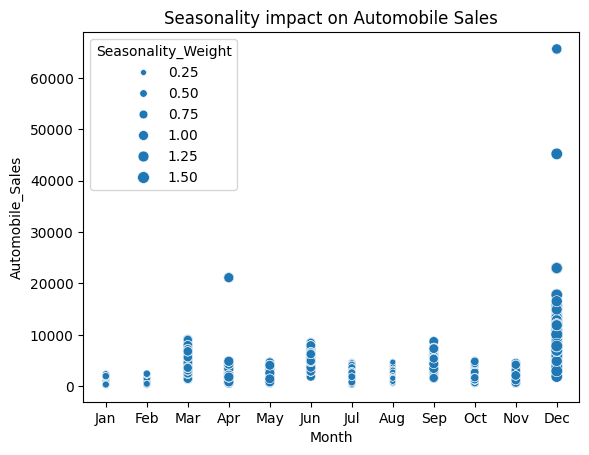

In [11]:
non_rec_data = df[ df['Recession'] == 0 ]
size = non_rec_data['Seasonality_Weight']

sns.scatterplot(data = non_rec_data, x = 'Month', y = 'Automobile_Sales', size = 'Seasonality_Weight')

plt.xlabel('Month')
plt.ylabel('Automobile_Sales')
plt.title('Seasonality impact on Automobile Sales')
plt.show()

<details>
<summary>Inference</summary>
From this plot, it is evident that seasonality has not affected on the overall sales. However, there is a drastic raise in sales in the month of April and December<br><br></details>


---


 ### TASK 1.6: develop a scatter plot to identify the relationship between consumer confidence and automobile sales during recessions.



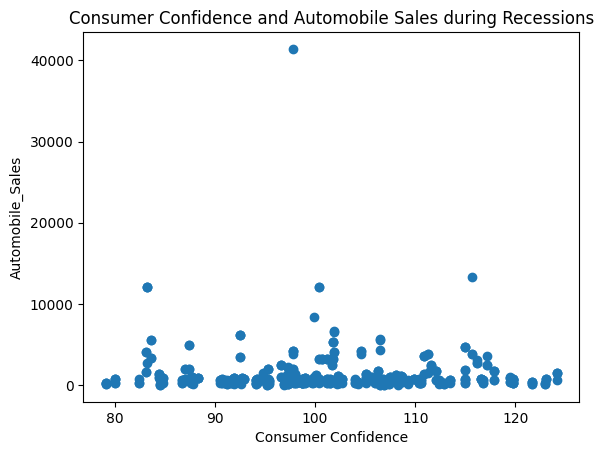

In [12]:
rec_data = df[ df['Recession'] == 1 ]


plt.scatter(rec_data['Consumer_Confidence'], rec_data['Automobile_Sales'])

plt.xlabel('Consumer Confidence')
plt.ylabel('Automobile_Sales')
plt.title( 'Consumer Confidence and Automobile Sales during Recessions')
plt.show()


 ### How does consumer confidence relate to automobile sales during recessions?
 <br>


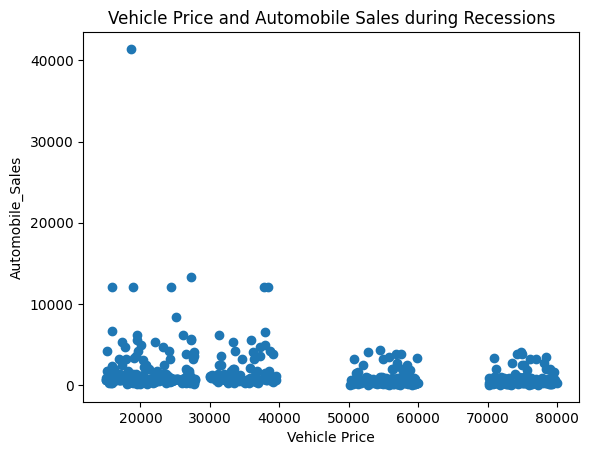

In [13]:
rec_data = df[ df['Recession'] == 1 ]


plt.scatter(rec_data['Price'], rec_data['Automobile_Sales'])

plt.xlabel('Vehicle Price')
plt.ylabel('Automobile_Sales')
plt.title( 'Vehicle Price and Automobile Sales during Recessions')
plt.show()

<details><summary>Inference</summary>
The graphs indicate that during recessions, higher consumer confidence tends to boost automobile sales, while higher vehicle prices generally correspond to lower sales. This highlights the strong influence of both consumer sentiment and affordability on purchasing decisions during economic downturns.<br><br></details>




----


 ### TASK 1.7:  Display the portion of advertising expenditure of XYZAutomotives during recession and non-recession periods.
 <br> 


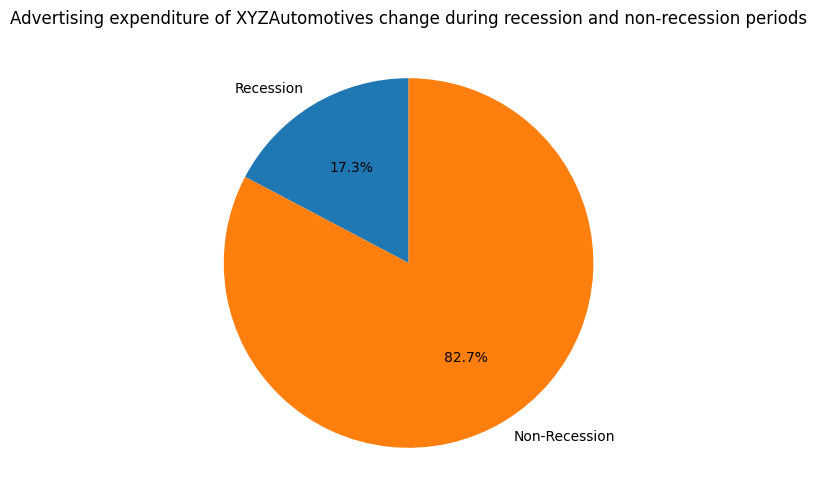

In [14]:
Rdata = df[df['Recession'] == 1]
NRdata = df[df['Recession'] == 0]
RAtotal = Rdata['Advertising_Expenditure'].sum()
NRAtotal = NRdata['Advertising_Expenditure'].sum()

# Create a pie chart for the advertising expenditure 
plt.figure(figsize=(8, 6))

labels = ['Recession', 'Non-Recession']
sizes = [RAtotal, NRAtotal]
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)

plt.title('Advertising expenditure of XYZAutomotives change during recession and non-recession periods')

plt.show()

####  what insights do you find on the advertisement expenditure during recession and non recession periods?<br>


<details><summary>Inference</summary>
It seems XYZAutomotives has been spending much more on the advertisements during non-recession periods as compared to during recession times. Fair enough!<br><br></details>


---


### TASK 1.8: To display the total Advertisement expenditure for each vehicle type during recession period.<br>
Can we observe the share of each vehicle type in total expenditure during recessions? 


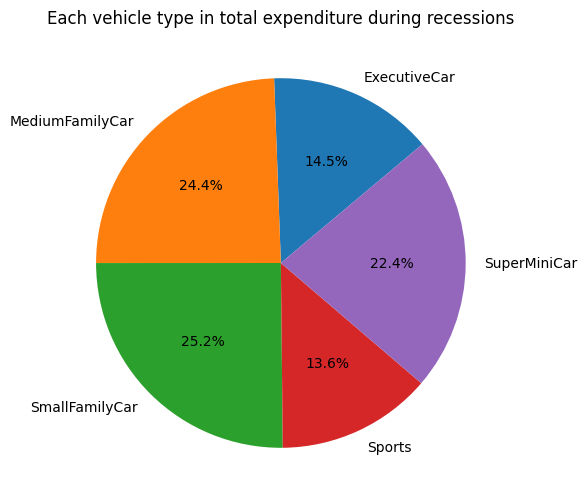

In [15]:
rec_AE = df[df['Recession'] == 1].groupby('Vehicle_Type')['Advertising_Expenditure'].sum().reset_index()
labels = rec_AE['Vehicle_Type']
value = rec_AE['Advertising_Expenditure']

plt.figure(figsize=(8, 6))

plt.pie(value, labels=labels, autopct='%1.1f%%', startangle=40)

plt.title('Each vehicle type in total expenditure during recessions')

plt.show()

<details>
<summary>Inference</summary>
During recession the advertisements were mostly focued on low price range vehicle. A wise decision!<br><br></details>



----


 ### TASK 1.9: To analyse the effect of the unemployment rate on vehicle type and sales during the Recession Period.<br>



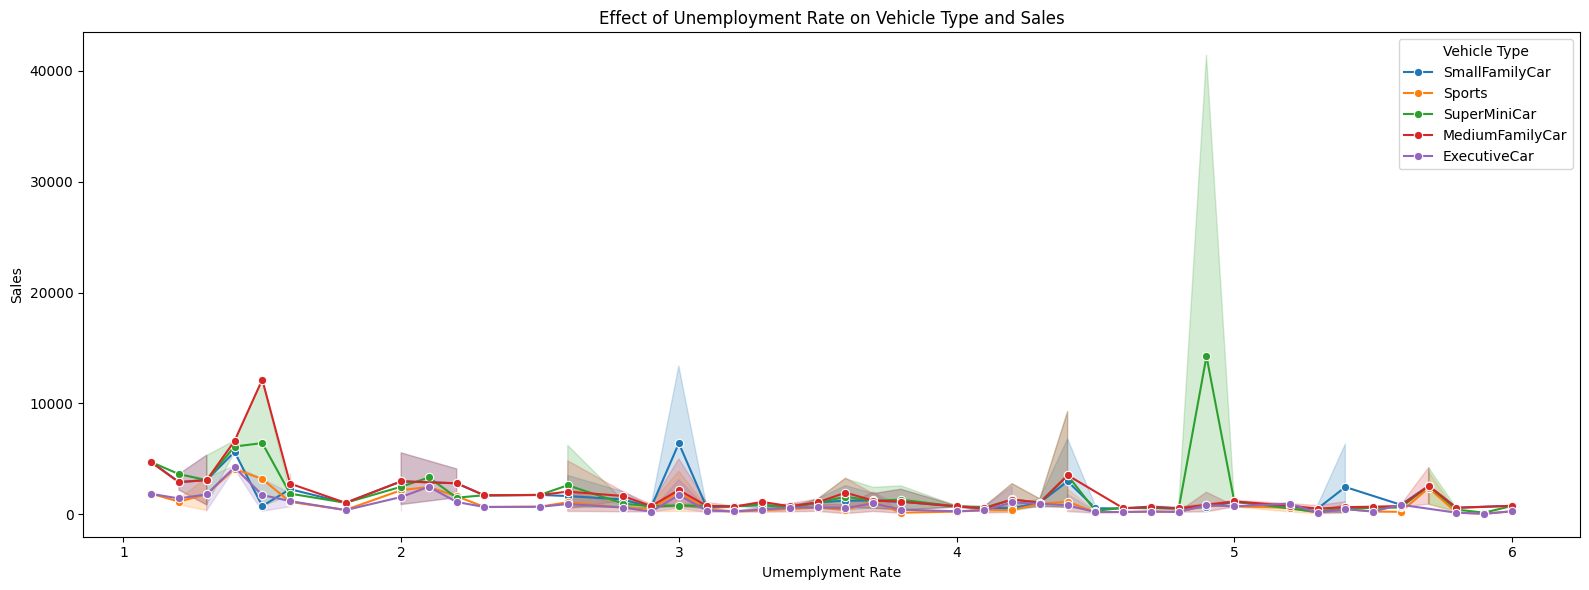

In [16]:
df_rec = df[df['Recession'] == 1]

plt.figure(figsize = (16, 6))
sns.lineplot(
    data = df_rec,
    x = 'unemployment_rate',
    y = 'Automobile_Sales',
    hue = 'Vehicle_Type',
    marker = 'o'
)
# Customize labels, legend, and title
plt.title('Effect of Unemployment Rate on Vehicle Type and Sales')
plt.xlabel('Umemplyment Rate')
plt.ylabel('Sales')
plt.legend(title='Vehicle Type')

# Show plot
plt.tight_layout()
plt.show()


<details><summary>Inference</summary>
The plot shows that automobile sales decline as unemployment rates rise during a recession, with sharp drops beyond 3%. SuperMiniCars, SmallFamilyCars, and MediumFamilyCars exhibit high volatility, reflecting their sensitivity to economic uncertainty and changing consumer priorities.<br><br>
</details>


---


### TASK 1.10 Create a map on the hightest sales region/offices of the company during recession period <br>


In [17]:
import requests

url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-DV0101EN-SkillsNetwork/Data%20Files/us-states.json"

response = requests.get(url)

if response.status_code == 200:
    with open("us-states.json", "wb") as f:
        f.write(response.content)
        print('File Saved Successful')
else:
    print('Error Occured')

File Saved Successful


In [18]:
# Filter the data for the recession period and specific cities
recession_data = df[df['Recession'] == 1]

# Calculate the total sales by city
sales_by_city = recession_data.groupby('City')['Automobile_Sales'].sum().reset_index()

# Create a base map centered on the United States
map1 = folium.Map(location=[37.0902, -95.7129], zoom_start=4)

# Create a choropleth layer using Folium
choropleth = folium.Choropleth(
    geo_data= 'us-states.json',  # GeoJSON file with state boundaries
    data=sales_by_city,
    columns=['City', 'Automobile_Sales'],
    key_on='feature.properties.name',
    fill_color='YlOrRd',
    fill_opacity=0.7,
    line_opacity=0.2,
    legend_name='Automobile Sales during Recession'
).add_to(map1)

# Add tooltips to the choropleth layer
choropleth.geojson.add_child(
    folium.features.GeoJsonTooltip(['name'], labels=True)
)
map1

<details><summary>Inference</summary>
The plot shows that the density of sales across Four different branches in US during recession <br><br>
</details>